In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import glob
import re
from scipy.stats import chi2
import os

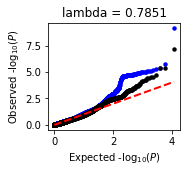

In [2]:
import scipy.stats
from scipy.stats import chi2
import matplotlib.lines as mlines
def parse(assoc):
    df = pd.read_table(assoc)
    df['P'] = -(np.log10(df['p_lrt']))
    df['P_bi'] = (np.log10(df['p_lrt']))
    space=2000000
    df['position'] = np.select([df['chr'] == 1, 
                                                df['chr'] == 2, 
                                                df['chr'] == 3, 
                                                df['chr'] == 4, 
                                                df['chr'] == 5],
                        [df['ps'], 
                        df['ps'] + 30427671 + space, 
                        df['ps'] + 30427671 + 19698289 + space * 2,
                        df['ps'] + 30427671 + 19698289 + 23459830 + space * 3,
                        df['ps'] + 30427671 + 19698289 + 23459830 + 18585056 + space * 4])
    return(df)

def observed(dataframe):
    df=dataframe['P'].to_numpy()
    df=np.sort(df)
    return(df)
classic=parse('FO_leaf_B_blues.assoc.txt.gz')
classic_observed=observed(classic)

Chr5_282011=parse('FO_leaf_B_blues_chr3_22436584_cov.assoc.txt.gz')
Chr5_282011_observed=observed(Chr5_282011)

expected=np.linspace(1, 1/(classic.shape[0]),classic.shape[0])
expected=-np.log10(expected)
expected=np.sort(expected)

cm = 1/2.54
fig = plt.figure(figsize=(6*cm,5*cm))
ax = sns.scatterplot(x=expected,
                y=classic_observed,
                marker='o',
                s=20,
                color='k',
                linewidth=0,
                zorder=5)
ax = sns.scatterplot(x=expected,
                y=Chr5_282011_observed,
                marker='o',
                color='b',
                s=20,
                linewidth=0,
                zorder=4)

ax = sns.lineplot(x=expected,
                y=expected,
                color='r',
                linestyle='--',
                linewidth=2,
                zorder=6)

# legend_elements = [mlines.Line2D([0], [0],color='w', marker='o',markerfacecolor='k',
#                           markersize=8, label='all SNPs'),
#                    mlines.Line2D([0], [0],color='w', marker='o',markerfacecolor='b',
#                           markersize=8, label='with Chr5:282011\nas covariate')]
                

# ax.legend(handles=legend_elements,loc='best',frameon=False)
Lambda=chi2.ppf(1 - np.median(classic['p_lrt']), 1)/chi2.ppf(0.5, 1)
ax.set_title('lambda = {:.4f}'.format(Lambda))
ax.set_xlabel('Expected -log$_{10}$($\itP$)',fontsize=10)
ax.set_ylabel('Observed -log$_{10}$($\itP$)',fontsize=10)
# plt.savefig("FigS4b.pdf", format="pdf",bbox_inches="tight",facecolor="w")
plt.savefig("FigS2b.png", format="png",bbox_inches="tight",facecolor="w",dpi=400)